
# Análisis de Datos y preparación del dataset
## Proyecto VRCE

Índice:

1) Introducción
2) Objetivo
3) Limpieza
4) Análisis


## 1. Introducción

Se analiza la estructura inicial del repositorio de datos utilizado en el proyecto Valorant Role Compliance Evaluation (VRCE), cuyo objetivo es desarrollar un sistema de inteligencia artificial capaz de evaluar el rendimiento individual de jugadores profesionales de Valorant.

Los datos no se encuentran consolidados en un único dataset listo para el análisis. En su lugar, el repositorio está organizado siguiendo una lógica similar a la de un data lake, donde la información se almacena de forma distribuida y segmentada por temporadas competitivas. Dentro de la carpeta principal /data existen distintas particiones anuales (vct_2021, vct_2022, ..., vct_2025) que contienen información específica de cada periodo, así como una carpeta global /all_ids que actúa como catálogo de identificadores del ecosistema competitivo.

Cada partición anual se divide a su vez en subcarpetas que representan diferentes tipos de información, como agents, ids, matches y player_stats, lo que permite separar las entidades principales del sistema competitivo. Esta organización facilita el almacenamiento histórico de los datos, aunque implica que el dataset final aún no está completamente consolidado y requiere procesos posteriores de integración y preparación antes de ser utilizado para modelado.

## 2. Objetivo

El objetivo de esta exploración inicial es comprender la organización del data lake y el papel de cada uno de sus componentes antes de realizar el análisis de datos. En particular, se busca identificar la estructura del repositorio, los diferentes tipos de archivos disponibles y cómo se relacionan entre sí las entidades principales del sistema competitivo, como jugadores, equipos, partidas y torneos.

Esta etapa es fundamental para establecer una base sólida para el análisis exploratorio de datos (EDA), ya que permitirá determinar qué fuentes contienen la información relevante para el proyecto, cómo deben integrarse los distintos conjuntos de datos y cuál será la unidad de análisis más adecuada para evaluar el rendimiento competitivo de los jugadores.

## 3. Limpieza

### 1) Importación de librerías

In [ ]:
import pandas as pd
import numpy as np
import os

# Visualización
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocesamiento
from sklearn.preprocessing import MinMaxScaler, LabelEncoder

# Modelos
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.model_selection import GridSearchCV

#Calculo de métricas
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

### 2) Definir las rutas del Data Lake

In [2]:
DATA_PATH = "data/vct_2025"

agents_path = os.path.join(DATA_PATH, "agents")
ids_path = os.path.join(DATA_PATH, "ids")
matches_path = os.path.join(DATA_PATH, "matches")
player_stats_path = os.path.join(DATA_PATH, "players_stats")

### 3) Cargar datasets principales

In [3]:
# Player stats (dataset principal)
player_stats = pd.read_csv(os.path.join(player_stats_path, "players_stats.csv"))

# IDs
players_ids = pd.read_csv(os.path.join(ids_path, "players_ids.csv"))
teams_ids = pd.read_csv(os.path.join(ids_path, "teams_ids.csv"))

# Matches
maps_scores = pd.read_csv(os.path.join(matches_path, "maps_scores.csv"))
overview = pd.read_csv(os.path.join(matches_path, "overview.csv"))

# Ver tamaño
print("player_stats:", player_stats.shape)
print("players_ids:", players_ids.shape)
print("teams_ids:", teams_ids.shape)
print("maps_scores:", maps_scores.shape)
print("overview:", overview.shape)

player_stats: (17996, 25)
players_ids: (349, 2)
teams_ids: (58, 2)
maps_scores: (1277, 16)
overview: (53226, 21)


### 4) Inspección inicial de player_stats

* Información general

In [4]:
player_stats.head()

,Tournament,Stage,Match Type,Player,Teams,Agents,Rounds Played,Rating,Average Combat Score,Kills:Deaths,"Kill, Assist, Trade, Survive %",Average Damage Per Round,Kills Per Round,Assists Per Round,First Kills Per Round,First Deaths Per Round,Headshot %,Clutch Success %,Clutches (won/played),Maximum Kills in a Single Map,Kills,Deaths,Assists,First Kills,First Deaths
0,Valorant Champions 2025,Playoffs,Upper Quarterfinals,Boo,Team Heretics,astra,26,0.68,129.0,0.61,69%,89.0,0.42,0.15,0.12,0.12,44%,NaN,0/4,11,11,18,4,3,3
1,Valorant Champions 2025,Playoffs,Upper Quarterfinals,Boo,Team Heretics,omen,19,0.46,98.0,0.40,42%,55.0,0.32,0.26,0.05,0.26,37%,33%,1/3,6,6,15,5,1,5
2,Valorant Champions 2025,Playoffs,Upper Quarterfinals,Boo,Team Heretics,"astra, omen",45,0.59,114.0,0.52,58%,74.0,0.38,0.20,0.09,0.18,41%,14%,1/7,11,17,33,9,4,8
3,Valorant Champions 2025,Playoffs,Upper Quarterfinals,RieNs,Team Heretics,fade,26,1.21,219.0,1.13,81%,147.0,0.69,0.38,0.08,0.04,23%,33%,1/3,18,18,16,10,2,1
4,Valorant Champions 2025,Playoffs,Upper Quarterfinals,RieNs,Team Heretics,sova,19,1.02,220.0,0.75,58%,142.0,0.63,0.26,0.05,0.05,28%,NaN,0/4,12,12,16,5,1,1


* Información detallada

In [5]:

player_stats.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17996 entries, 0 to 17995
Data columns (total 25 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Tournament                      17996 non-null  object 
 1   Stage                           17996 non-null  object 
 2   Match Type                      17996 non-null  object 
 3   Player                          17996 non-null  object 
 4   Teams                           17996 non-null  object 
 5   Agents                          17996 non-null  object 
 6   Rounds Played                   17996 non-null  int64  
 7   Rating                          16604 non-null  float64
 8   Average Combat Score            17986 non-null  float64
 9   Kills:Deaths                    17996 non-null  float64
 10  Kill, Assist, Trade, Survive %  16692 non-null  object 
 11  Average Damage Per Round        16626 non-null  float64
 12  Kills Per Round                 

* Estadísctica descriptiva

In [6]:
player_stats.describe()

,Rounds Played,Rating,Average Combat Score,Kills:Deaths,Average Damage Per Round,Kills Per Round,Assists Per Round,First Kills Per Round,First Deaths Per Round,Maximum Kills in a Single Map,Kills,Deaths,Assists,First Kills,First Deaths
count,17996.000000,16604.000000,17986.000000,17996.000000,16626.000000,17996.000000,17996.000000,16645.000000,16646.000000,17996.000000,17996.000000,17996.000000,17996.000000,17996.000000,17996.000000
mean,56.905979,0.988747,195.649283,1.036644,128.316312,0.688337,0.279657,0.099878,0.101812,16.917648,39.377195,39.402367,16.060736,5.273727,5.281118
std,73.473854,0.275065,49.065678,0.451347,30.629254,0.192783,0.147140,0.071383,0.068724,5.739903,52.716300,50.380248,23.288620,8.685712,8.120614
min,13.000000,0.030000,22.000000,0.000000,20.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000
25%,22.000000,0.820000,163.000000,0.770000,108.000000,0.560000,0.170000,0.050000,0.050000,13.000000,15.000000,15.000000,5.000000,1.000000,1.000000
50%,37.000000,0.980000,193.000000,0.980000,127.000000,0.680000,0.260000,0.090000,0.090000,17.000000,24.000000,24.000000,9.000000,3.000000,3.000000
75%,61.000000,1.150000,225.000000,1.210000,146.000000,0.800000,0.360000,0.140000,0.140000,21.000000,41.000000,41.000000,17.000000,6.000000,6.000000
max,696.000000,2.660000,509.000000,18.000000,307.000000,1.950000,1.570000,0.500000,0.530000,42.000000,579.000000,485.000000,345.000000,137.000000,111.000000


### 5) Limpieza de datos

* Verificar valores nulos

In [7]:
player_stats.isnull().sum().sort_values(ascending=False)

Clutch Success %                  11337
Clutches (won/played)              4733
Rating                             1392
Average Damage Per Round           1370
First Kills Per Round              1351
First Deaths Per Round             1350
Headshot %                         1308
Kill, Assist, Trade, Survive %     1304
Average Combat Score                 10
Agents                                0
Rounds Played                         0
Player                                0
Teams                                 0
Match Type                            0
Stage                                 0
Tournament                            0
Kills:Deaths                          0
Assists Per Round                     0
Kills Per Round                       0
Maximum Kills in a Single Map         0
Kills                                 0
Deaths                                0
Assists                               0
First Kills                           0
First Deaths                          0


* Eliminar nulos en columnas esenciales

In [ ]:
# Solo eliminar nulos en columnas esenciales, no en todo
columnas_criticas = ["Player", "Agents", "Average Combat Score",
                     "Kills Per Round", "Kills:Deaths"]
df = player_stats.dropna(subset=columnas_criticas)
df = df.drop_duplicates()
print("Filas después de limpieza:", len(df))

Filas después de limpieza: 17986


* Eliminar duplicados

In [9]:
df = df.drop_duplicates()

* Correción de tipos

In [10]:
df.dtypes

Tournament                         object
Stage                              object
Match Type                         object
Player                             object
Teams                              object
Agents                             object
Rounds Played                       int64
Rating                            float64
Average Combat Score              float64
Kills:Deaths                      float64
Kill, Assist, Trade, Survive %     object
Average Damage Per Round          float64
Kills Per Round                   float64
Assists Per Round                 float64
First Kills Per Round             float64
First Deaths Per Round            float64
Headshot %                         object
Clutch Success %                   object
Clutches (won/played)              object
Maximum Kills in a Single Map       int64
Kills                               int64
Deaths                              int64
Assists                             int64
First Kills                       

In [ ]:
## Convertir porcentajes a valores numéricos
# Headshot %
df["Headshot %"] = pd.to_numeric(
    df["Headshot %"].astype(str).str.replace("%", "", regex=False),
    errors="coerce") / 100

df["Clutch Success %"] = pd.to_numeric(
    df["Clutch Success %"].astype(str).str.replace("%", "", regex=False),
    errors="coerce") / 100

# Clutch Success %
clutch_split = df["Clutches (won/played)"].str.split("/", expand=True)
df["Clutches_Won"] = pd.to_numeric(clutch_split[0], errors="coerce")
df["Clutches_Played"] = pd.to_numeric(clutch_split[1], errors="coerce")
df["Clutch_Success_Ratio"] = np.where(
    df["Clutches_Played"] > 0,
    df["Clutches_Won"] / df["Clutches_Played"], 0
)
df.drop(columns=["Clutches (won/played)"], inplace=True)

# Renombrar
df.rename(columns={"Kills:Deaths": "KDR"}, inplace=True)

# Convertir "Kills:Deaths" a valor numérico
df["KDR"] = pd.to_numeric(df["KDR"], errors="coerce")

* Mapear agentes a roles

In [12]:
df["Agents"] = df["Agents"].astype(str)

# separar múltiples agentes
df["Agents"] = df["Agents"].str.split(",").str[0].str.strip()

In [13]:
agent_to_role = {
    "Jett": "Duelist", "Raze": "Duelist", "Reyna": "Duelist",
    "Phoenix": "Duelist", "Yoru": "Duelist", "Neon": "Duelist",
    "Iso": "Duelist", "Waylay": "Duelist",          # ← Waylay agregado

    "Brimstone": "Controller", "Omen": "Controller",
    "Viper": "Controller", "Astra": "Controller", "Harbor": "Controller",
    "Clove": "Controller",

    "Sage": "Sentinel", "Cypher": "Sentinel",
    "Killjoy": "Sentinel", "Chamber": "Sentinel",
    "Deadlock": "Sentinel", "Vyse": "Sentinel",

    "Sova": "Initiator", "Breach": "Initiator",
    "Skye": "Initiator", "Kayo": "Initiator",       # ← KAY/O como "Kayo" por el .title()
    "Fade": "Initiator", "Gekko": "Initiator",
    "Tejo": "Initiator"
}

# Agentes y roles
df["Agents"] = df["Agents"].astype(str).str.split(",").str[0].str.strip().str.title()

df["Role"] = df["Agents"].map(agent_to_role)

# Ver si quedaron agentes sin mapear
sin_mapear = df[df["Role"].isna()]["Agents"].unique()
print("Sin mapear:", sin_mapear)
print("Filas con Role válido:", df["Role"].notna().sum())

# Eliminar los sin mapear
df = df.dropna(subset=["Role"])
print("Filas finales:", len(df))

Sin mapear: []
Filas con Role válido: 17986
Filas finales: 17986


### 6) Identificar columnas a trabajar

In [14]:
player_stats.columns

Index(['Tournament', 'Stage', 'Match Type', 'Player', 'Teams', 'Agents',
       'Rounds Played', 'Rating', 'Average Combat Score', 'Kills:Deaths',
       'Kill, Assist, Trade, Survive %', 'Average Damage Per Round',
       'Kills Per Round', 'Assists Per Round', 'First Kills Per Round',
       'First Deaths Per Round', 'Headshot %', 'Clutch Success %',
       'Clutches (won/played)', 'Maximum Kills in a Single Map', 'Kills',
       'Deaths', 'Assists', 'First Kills', 'First Deaths'],
      dtype='object')

### 7) Limpieza de columnas innecesarias

In [ ]:
features = [
    "Player",
    "Average Combat Score",
    "Average Damage Per Round",
    "Kills Per Round",
    "Assists Per Round",
    "First Kills Per Round",
    "First Deaths Per Round",
    "Headshot %",
    "Clutch_Success_Ratio",
    "Clutches_Won",
    "KDR",
    "Agents",
    "Role"
]

df_model = df[features].copy()
print("df_model filas:", len(df_model))

df_model filas: 17986


### 8) Ingeniería de Features

In [16]:
df_model["Offensive_Index"] = (
    df_model["Kills Per Round"] +
    df_model["First Kills Per Round"]
)

df_model["Survival_Index"] = 1 - df_model["First Deaths Per Round"]

df_model["Clutch_Index"] = (
    df_model["Clutch_Success_Ratio"] *
    df_model["Clutches_Won"]
)

### 9) Score por rol

In [17]:
def compute_score(row):
    role = row["Role"]

    adr = row["Average Damage Per Round"]
    kpr = row["Kills Per Round"]
    apr = row["Assists Per Round"]
    fkpr = row["First Kills Per Round"]
    fdpr = row["First Deaths Per Round"]
    clutch = row["Clutch_Success_Ratio"]

    if role == "Duelist":
        score = 0.4*fkpr + 0.3*kpr - 0.2*fdpr + 0.1*adr

    elif role == "Controller":
        score = 0.35*apr + 0.25*adr + 0.2*kpr - 0.2*fdpr

    elif role == "Sentinel":
        score = 0.4*clutch + 0.35*(1 - fdpr) + 0.25*apr

    elif role == "Initiator":
        score = 0.35*apr + 0.3*kpr + 0.2*adr + 0.15*fkpr

    else:
        score = np.nan

    return score

df_model["role_score_raw"] = df_model.apply(compute_score, axis=1)

### Cálculo del Role Score

Se calcula un puntaje (`role_score_raw`) para cada jugador en función de su rol asignado. Cada rol tiene una fórmula distinta que pondera las métricas más relevantes para ese estilo de juego:

- **Duelist**: prioriza primeras kills y kills por ronda, penaliza primeras muertes.
- **Controller**: valora asistencias, daño promedio y kills, penaliza primeras muertes.
- **Sentinel**: se basa en ratio de clutch, sobrevivencia (1 - fdpr) y asistencias.
- **Initiator**: equilibra asistencias, kills, daño y primeras kills.

Si el rol no coincide con ninguno de los anteriores, el score se asigna como `NaN` y se excluye del modelo.

Finalmente, el score raw se normaliza entre 0 y 1 usando `MinMaxScaler` para obtener `role_score`, que es la variable objetivo del modelo.

In [18]:
df_model["role_score_raw"] = df_model.apply(compute_score, axis=1)
print("Valores calculados:", df_model["role_score_raw"].notna().sum())
print(df_model[["Player", "Role", "role_score_raw"]].head())
scaler = MinMaxScaler()
df_model["role_score"] = scaler.fit_transform(df_model[["role_score_raw"]]).flatten()
print("role_score listo ✓")
print(df_model["role_score"].describe())

Valores calculados: 16628
  Player        Role  role_score_raw
0    Boo  Controller         22.3625
1    Boo  Controller         13.8530
2    Boo  Controller         18.6100
3  RieNs   Initiator         29.7520
4  RieNs   Initiator         28.6875
role_score listo ✓
count    16628.000000
mean         0.258644
std          0.169921
min          0.000000
25%          0.156831
50%          0.273782
75%          0.381764
max          1.000000
Name: role_score, dtype: float64


### 10) Normalización

In [19]:
scaler = MinMaxScaler()
df_model["role_score"] = scaler.fit_transform(df_model[["role_score_raw"]]).flatten()

### 11) Encoding

In [20]:
le_agent = LabelEncoder()
le_role = LabelEncoder()

# Guardar versión string de Role para visualizaciones posteriores
df_model["Role_str"] = df_model["Role"].copy()

df_model["Agents"] = le_agent.fit_transform(df_model["Agents"])
df_model["Role"] = le_role.fit_transform(df_model["Role"])

### 12) Dataset final

In [21]:
# Limpiar NaN/inf antes de separar X e y
model_df = df_model.replace([np.inf, -np.inf], np.nan).dropna(subset=["role_score"]).copy()

X = model_df.drop(columns=["Player", "role_score", "role_score_raw", "Role_str"])
y = model_df["role_score"]

print("Filas válidas para modelado:", len(model_df))
print("NaN en y:", y.isna().sum())

X.head()

Filas válidas para modelado: 16628
NaN en y: 0


,Average Combat Score,Average Damage Per Round,Kills Per Round,Assists Per Round,First Kills Per Round,First Deaths Per Round,Headshot %,Clutch_Success_Ratio,Clutches_Won,KDR,Agents,Role,Offensive_Index,Survival_Index,Clutch_Index
0,129.0,89.0,0.42,0.15,0.12,0.12,0.44,0.000000,0.0,0.61,0,0,0.54,0.88,0.000000
1,98.0,55.0,0.32,0.26,0.05,0.26,0.37,0.333333,1.0,0.40,15,0,0.37,0.74,0.333333
2,114.0,74.0,0.38,0.20,0.09,0.18,0.41,0.142857,1.0,0.52,0,0,0.47,0.82,0.142857
3,219.0,147.0,0.69,0.38,0.08,0.04,0.23,0.333333,1.0,1.13,7,2,0.77,0.96,0.333333
4,220.0,142.0,0.63,0.26,0.05,0.05,0.28,0.000000,0.0,0.75,21,2,0.68,0.95,0.000000


In [22]:
df_model.to_csv("dataset_players_stats.csv", index=False)

### 13) División del Dataset (Garantizar la reproducibilidad)

In [ ]:
# Dividimos el dataset: 80% para entrenar, 20% para validar el modelo
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Muestras de entrenamiento: {X_train.shape[0]}")
print(f"Muestras de validación: {X_test.shape[0]}")

Muestras de entrenamiento: 13302
Muestras de validación: 3326


### 14) Entrenamiento y Validación Cruzada (Ejecuciones e iteraciones)

In [ ]:
# 1. Configuración de Random Forest con búsqueda de hiperparámetros y Cross-Validation (K=5)
rf_params = {
    'n_estimators': [100, 200],
    'max_depth': [10, 15, None],
    'min_samples_split': [2, 5]
}

rf_model = GridSearchCV(RandomForestRegressor(random_state=42), rf_params, cv=5, scoring='neg_root_mean_squared_error', n_jobs=-1)
rf_model.fit(X_train, y_train)
print(f"Mejor configuración Random Forest: {rf_model.best_params_}")

# 2. Configuración de XGBoost
xgb_params = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1]
}

xgb_model = GridSearchCV(XGBRegressor(random_state=42), xgb_params, cv=5, scoring='neg_root_mean_squared_error', n_jobs=-1)
xgb_model.fit(X_train, y_train)
print(f"Mejor configuración XGBoost: {xgb_model.best_params_}")

Mejor configuración Random Forest: {'max_depth': 15, 'min_samples_split': 2, 'n_estimators': 100}
Mejor configuración XGBoost: {'learning_rate': 0.1, 'max_depth': 7, 'n_estimators': 100}


### 14) Resultados: Cálculo de métricas

In [ ]:
# Predicciones con los mejores modelos
rf_preds = rf_model.predict(X_test)
xgb_preds = xgb_model.predict(X_test)

# Métricas para Random Forest
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_preds))
rf_r2 = r2_score(y_test, rf_preds)

# Métricas para XGBoost
xgb_rmse = np.sqrt(mean_squared_error(y_test, xgb_preds))
xgb_r2 = r2_score(y_test, xgb_preds)

print(f"Random Forest -> RMSE: {rf_rmse:.4f} | R2: {rf_r2:.4f}")
print(f"XGBoost       -> RMSE: {xgb_rmse:.4f} | R2: {xgb_r2:.4f}")

Random Forest -> RMSE: 0.0033 | R2: 0.9996
XGBoost       -> RMSE: 0.0028 | R2: 0.9997


In [26]:
df_model.to_csv("dataset_players_trained.csv", index=False)

## 4. Análisis

### 1) Gráfico de Predicción vs. Realidad (Actual vs. Predicted)

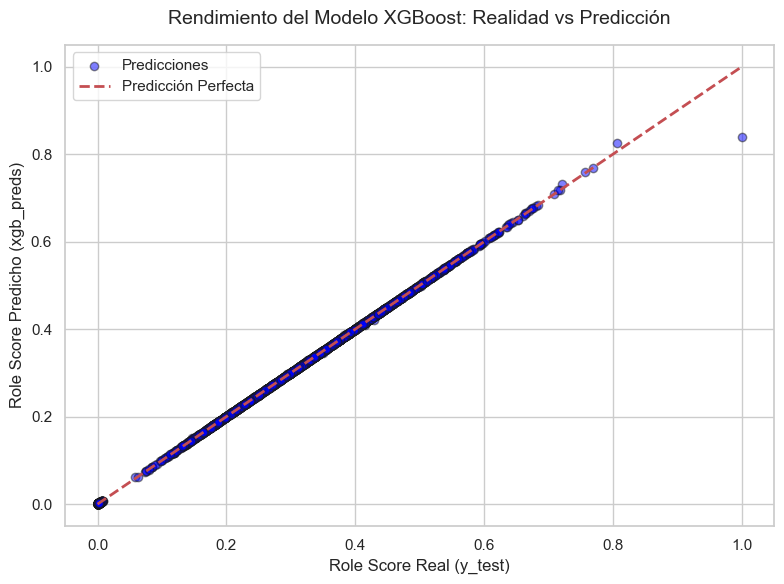

In [27]:
# Configuramos el estilo
sns.set_theme(style="whitegrid")
plt.figure(figsize=(8, 6))

# Dibujamos los puntos (Realidad vs Predicción de XGBoost)
plt.scatter(y_test, xgb_preds, alpha=0.5, color='blue', edgecolor='k', label='Predicciones')

# Dibujamos la línea de perfección (y = x)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Predicción Perfecta')

plt.title('Rendimiento del Modelo XGBoost: Realidad vs Predicción', fontsize=14, pad=15)
plt.xlabel('Role Score Real (y_test)', fontsize=12)
plt.ylabel('Role Score Predicho (xgb_preds)', fontsize=12)
plt.legend()
plt.tight_layout()
plt.show()

### 2) Análisis de Residuos (Residual Plot)

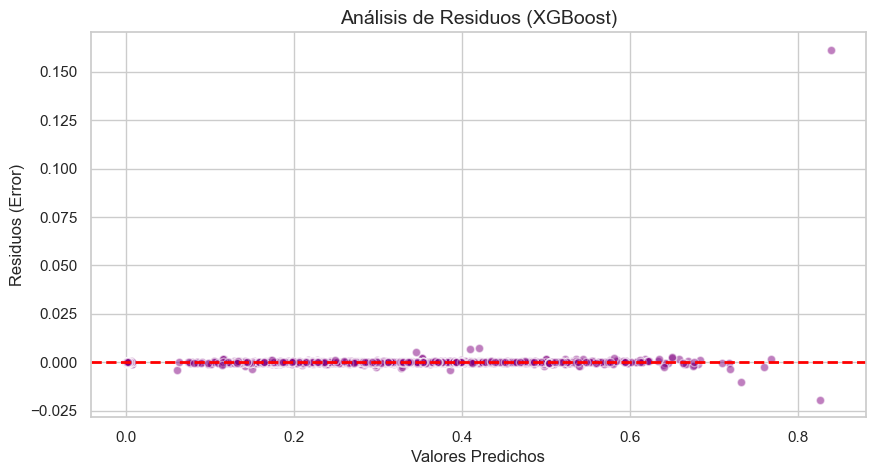

In [28]:
# Calculamos los residuos (Error)
residuos = y_test - xgb_preds

plt.figure(figsize=(10, 5))
plt.scatter(xgb_preds, residuos, alpha=0.5, color='purple', edgecolor='w')
plt.axhline(y=0, color='red', linestyle='--', lw=2)

plt.title('Análisis de Residuos (XGBoost)', fontsize=14)
plt.xlabel('Valores Predichos', fontsize=12)
plt.ylabel('Residuos (Error)', fontsize=12)
plt.show()

### 3) Top 15 Feature Importance (Mejorado)

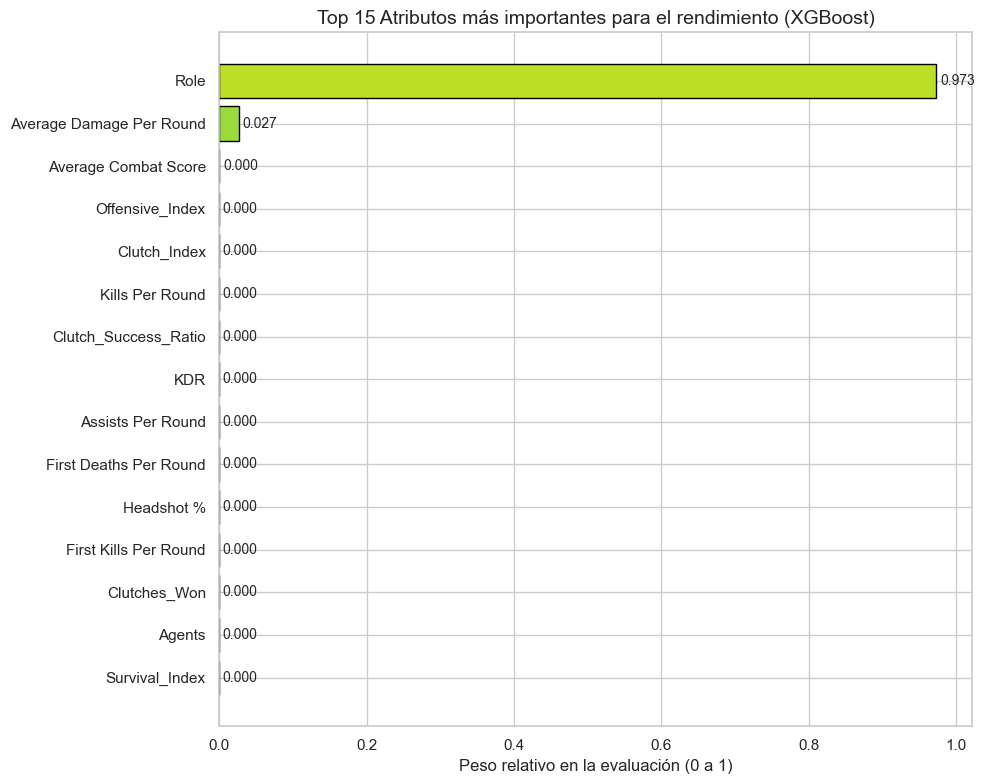

In [29]:
import pandas as pd
import numpy as np

# Extraemos la importancia y los nombres de las columnas
best_xgb = xgb_model.best_estimator_
importances = best_xgb.feature_importances_

# Creamos un DataFrame, lo ordenamos y cogemos solo el Top 15
feat_imp_df = pd.DataFrame({
    'Atributo': X.columns,
    'Importancia': importances
}).sort_values(by='Importancia', ascending=True).tail(15)

plt.figure(figsize=(10, 8))
# Usamos un mapa de color para resaltar los más importantes
colores = plt.cm.viridis(np.linspace(0.2, 0.9, len(feat_imp_df)))

plt.barh(feat_imp_df['Atributo'], feat_imp_df['Importancia'], color=colores, edgecolor='black')
plt.title('Top 15 Atributos más importantes para el rendimiento (XGBoost)', fontsize=14)
plt.xlabel('Peso relativo en la evaluación (0 a 1)', fontsize=12)

# Añadimos el valor numérico al final de cada barra para mayor claridad
for index, value in enumerate(feat_imp_df['Importancia']):
    plt.text(value + 0.005, index, f'{value:.3f}', va='center', fontsize=10)

plt.tight_layout()
plt.show()

### 1) Distribución de variables clave

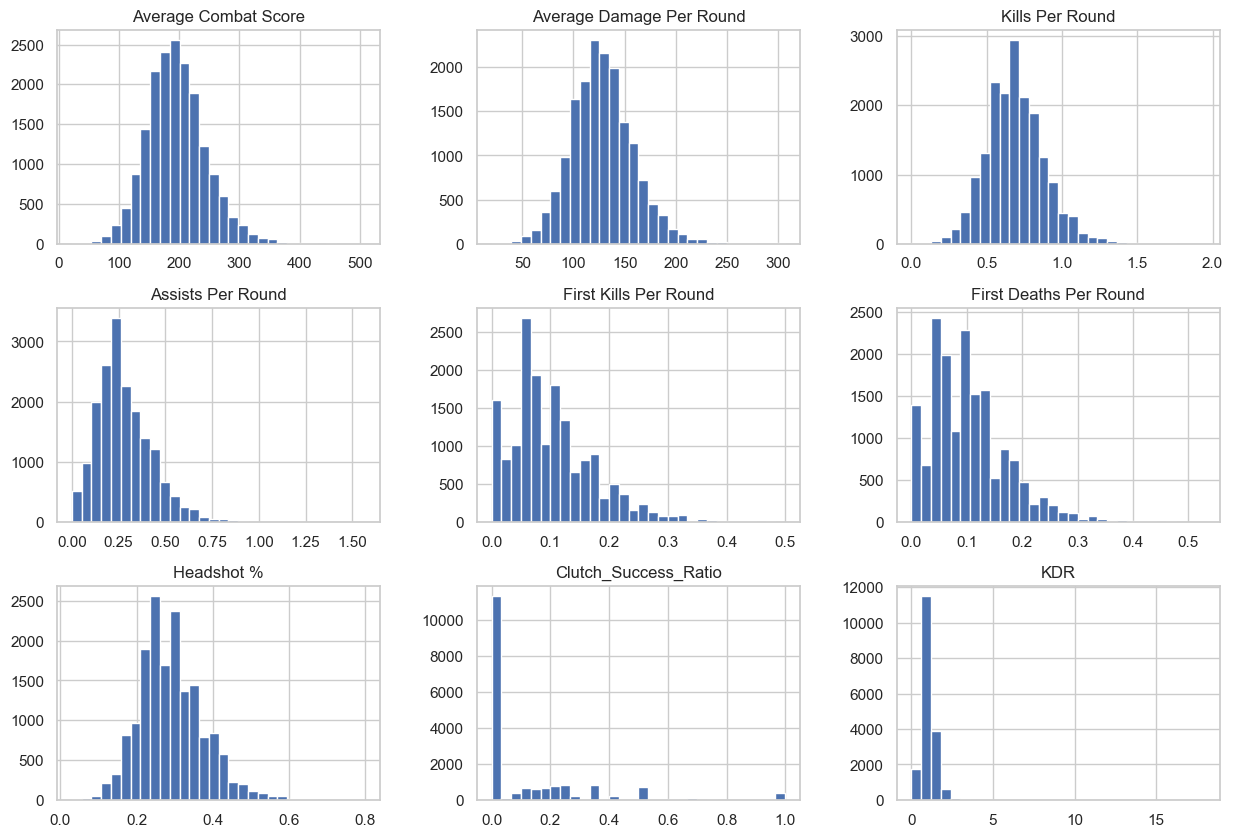

In [30]:
num_cols = [
    "Average Combat Score",
    "Average Damage Per Round",
    "Kills Per Round",
    "Assists Per Round",
    "First Kills Per Round",
    "First Deaths Per Round",
    "Headshot %",
    "Clutch_Success_Ratio",
    "KDR"
]

df_model[num_cols].hist(figsize=(15,10), bins=30)
plt.show()

### 2) Análisis de outliers

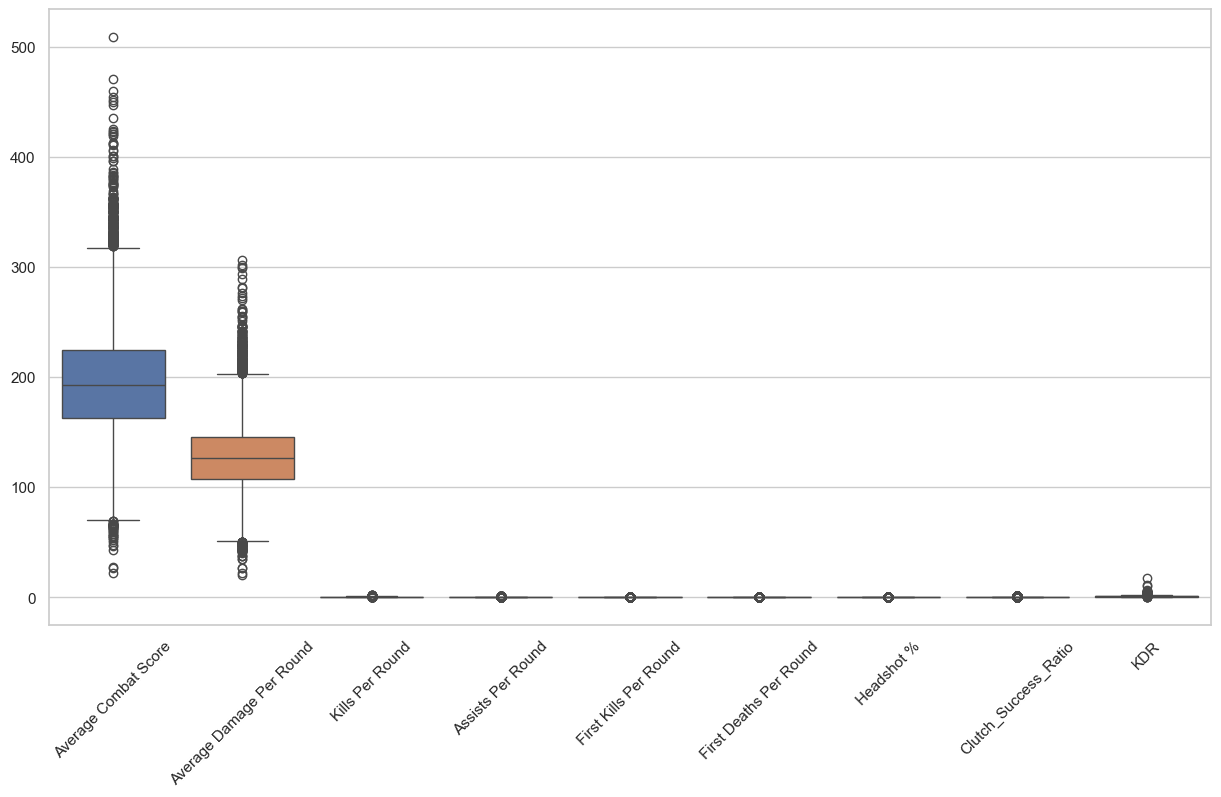

In [31]:
plt.figure(figsize=(15,8))
sns.boxplot(data=df_model[num_cols])
plt.xticks(rotation=45)
plt.show()

In [32]:
## Eliminar outliers usando IQR (ejecutar cuando sea necesario)

def remove_outliers(df, cols):
    for col in cols:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1

        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR

        df = df[(df[col] >= lower) & (df[col] <= upper)]

    return df

df_model = remove_outliers(df_model, num_cols)

### 3) Correlación entre variables

✔ Alta correlación (> 0.8)
* redundancia → elimina variables

✔ Relación con KPR
* KPR es central → muchas variables giran alrededor

✔ FDPR inversa
* alta FDPR → bajo rendimiento

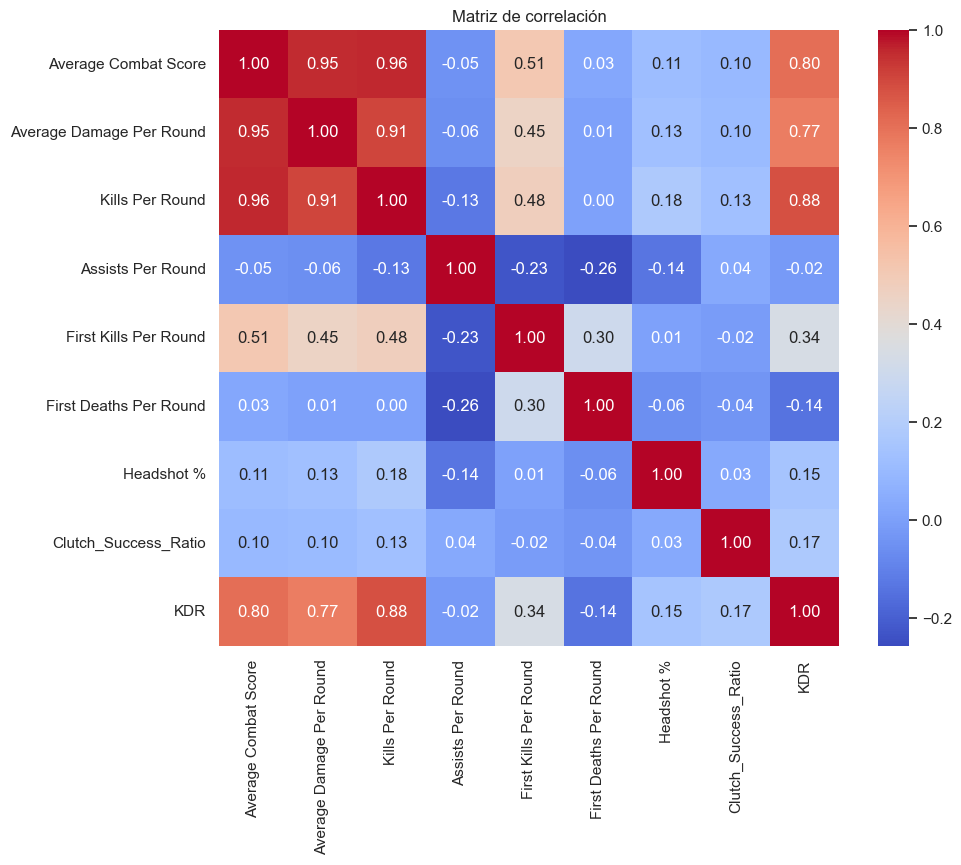

In [33]:
corr = df_model[num_cols].corr()

plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Matriz de correlación")
plt.show()

### 4) Correlación con el target

⚠️ Ejecutar cuando tengamos el modelo con el role_score

In [34]:
corr_target = df_model.select_dtypes(include="number").corr()["role_score"].sort_values(ascending=False)
print(corr_target)

role_score_raw              1.000000
role_score                  1.000000
Assists Per Round           0.420315
Average Damage Per Round    0.206433
Average Combat Score        0.201678
Survival_Index              0.178563
KDR                         0.174796
Kills Per Round             0.162950
Offensive_Index             0.108388
Clutch_Index                0.074544
Clutch_Success_Ratio        0.072769
Clutches_Won                0.070270
Agents                      0.022314
Headshot %                  0.013736
First Kills Per Round      -0.077083
First Deaths Per Round     -0.178563
Role                       -0.719569
Name: role_score, dtype: float64


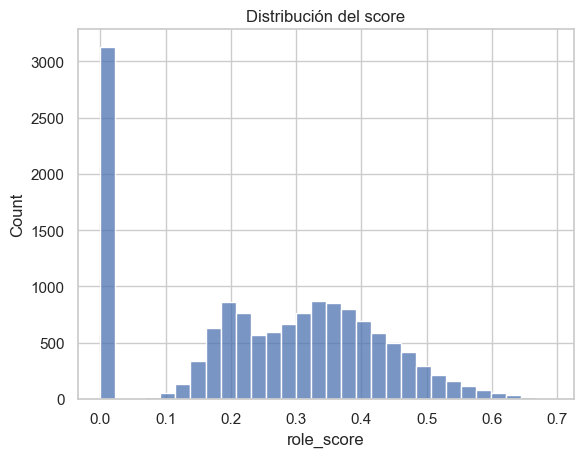

In [35]:
sns.histplot(df_model["role_score"], bins=30)
plt.title("Distribución del score")
plt.show()

### 5) Análisis por rol

* Duelist → más kills

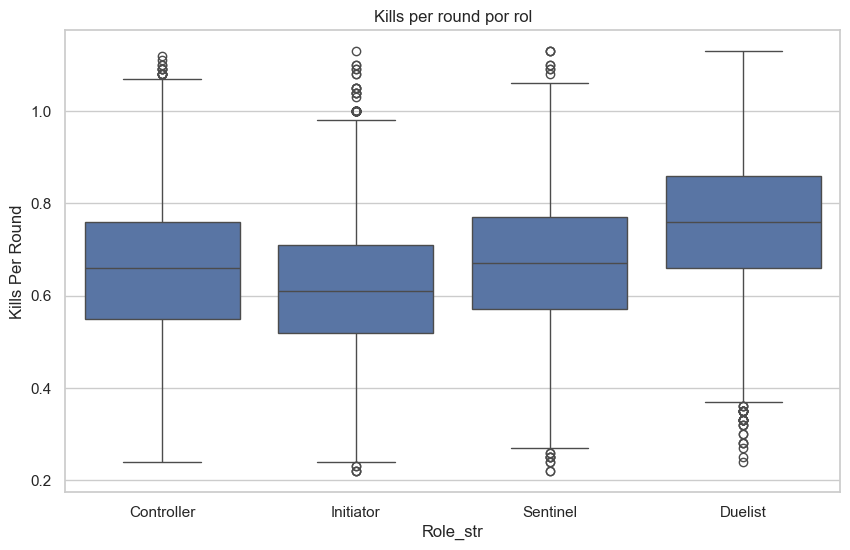

In [36]:
plt.figure(figsize=(10,6))
sns.boxplot(x="Role_str", y="Kills Per Round", data=df_model)
plt.title("Kills per round por rol")
plt.show()

* Initiator → más assists

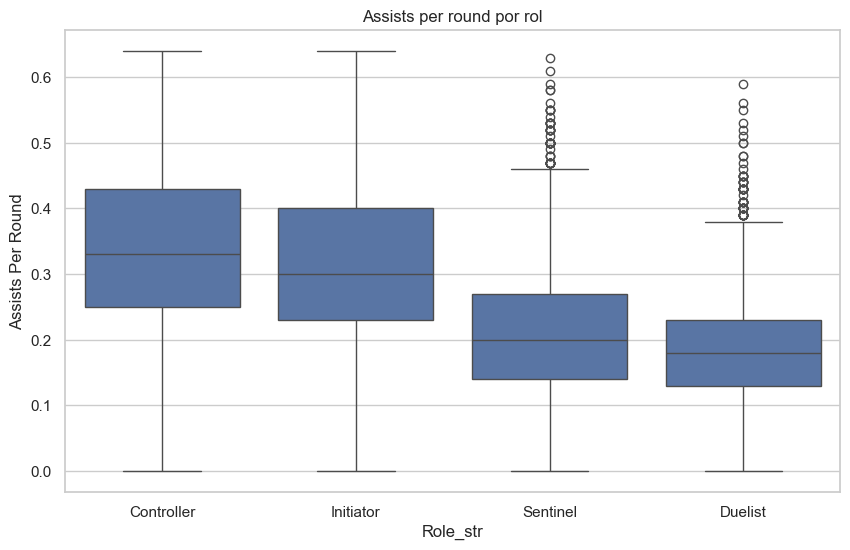

In [37]:
plt.figure(figsize=(10,6))
sns.boxplot(x="Role_str", y="Assists Per Round", data=df_model)
plt.title("Assists per round por rol")
plt.show()

* Sentinel → mejor clutch

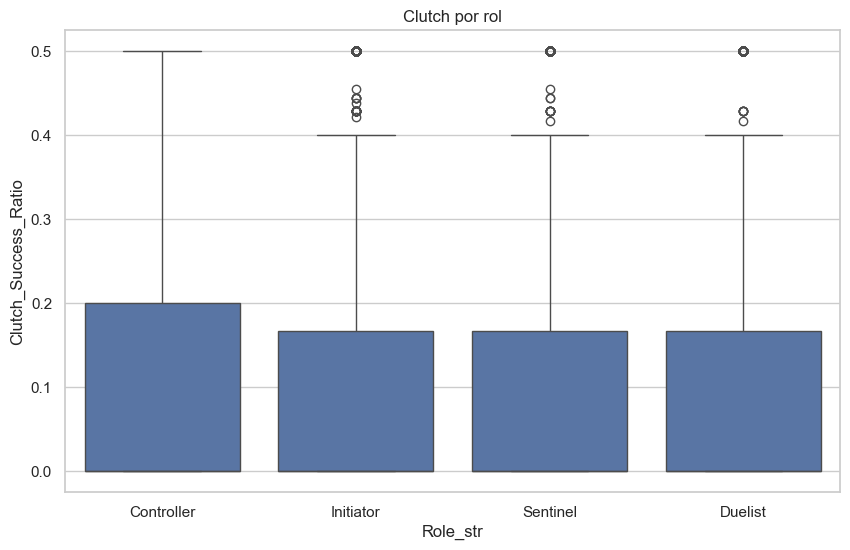

In [38]:
plt.figure(figsize=(10,6))
sns.boxplot(x="Role_str", y="Clutch_Success_Ratio", data=df_model)
plt.title("Clutch por rol")
plt.show()